# Modèle 1 — Principal Component Regression (PCR)
**Projet ML 2026 — UMONS | Groupe 3**

La PCR combine deux étapes :
1. **PCA** (Principal Component Analysis) → réduit la dimensionnalité des features
2. **Régression linéaire** → prédit `Ja in Prozent` sur les composantes principales

C'est particulièrement utile ici car nos features sont nombreuses (67) et potentiellement corrélées entre elles.

In [4]:
# Imports et configuration

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error

pd.set_option('display.float_format', '{:.4f}'.format)

# Chargement des données
train = pd.read_csv("../data/train_final.csv")
test  = pd.read_csv("../data/test_final.csv")

print(f"Train : {train.shape}")
print(f"Test  : {test.shape}")

test.head()

Train : (1559, 67)
Test  : (669, 66)


,Kantons-Nummer,Kanton,commune_id,Gemeinde,Stimmberechtigte,Residents,Change in %,Population density per km²,Foreign nationals in %,0-19 years,...,gini_steinka,mean_reink,median_reink,gini_reink,mean_reinka,median_reinka,gini_reinka,lat,lon,ref622_ja_prozent
0,1,Zürich,69,Wallisellen,9182.0000,15934.0000,16.6984,2481.9315,30.8523,19.2921,...,0.3340,94947.0000,73400.0000,0.3760,72533.0000,60500.0000,0.3170,47.4150,8.5967,20.5013
1,2,Bern / Berne,981,Niederbipp,3028.0000,4647.0000,14.5145,268.4575,24.1231,19.8408,...,0.2760,71407.0000,57400.0000,0.3320,55779.0000,49700.0000,0.2630,47.2658,7.6958,21.5809
2,22,Vaud,5432,Montherod,269.0000,515.0000,-5.3309,103.8306,27.9612,21.9417,...,0.3120,98853.0000,78750.0000,0.3940,66857.0000,59219.0000,0.2960,NaN,NaN,51.8868
3,2,Bern / Berne,387,Lengnau (BE),3335.0000,5071.0000,10.1673,684.3455,23.2104,19.3453,...,0.2690,70540.0000,57900.0000,0.3170,54963.0000,49300.0000,0.2570,47.1817,7.3667,22.1711
4,10,Fribourg / Freiburg,2194,Ferpicloz,186.0000,277.0000,6.1303,271.5686,13.7184,25.2708,...,0.2990,95068.0000,80100.0000,0.3570,66207.0000,58556.0000,0.2850,46.7500,7.1667,37.5000


In [5]:
# Séparation features / cible
y = train["Ja in Prozent"]

# One Hot Encoding sur Kanton
train_encoded = pd.get_dummies(train, columns=["Kanton"])
test_encoded  = pd.get_dummies(test,  columns=["Kanton"])

# Supprimer les colonnes inutiles
X = train_encoded.drop(columns=["Ja in Prozent", "Gemeinde", "commune_id"])
X_test = test_encoded.drop(columns=["Gemeinde", "commune_id"])

# Aligner les colonnes train et test (cantons manquants dans test → 0)
X_test = X_test.reindex(columns=X.columns, fill_value=0)

print(f"X train : {X.shape}")
print(f"X test  : {X_test.shape}")
print(f"y train : {y.shape}")
print(f"\nColonnes Kanton créées :")
print([col for col in X.columns if "Kanton" in col])

X train : (1559, 89)
X test  : (669, 89)
y train : (1559,)

Colonnes Kanton créées :
['Kantons-Nummer', 'Kanton_Aargau', 'Kanton_Appenzell Ausserrhoden', 'Kanton_Appenzell Innerrhoden', 'Kanton_Basel-Landschaft', 'Kanton_Basel-Stadt', 'Kanton_Bern / Berne', 'Kanton_Fribourg / Freiburg', 'Kanton_Genève', 'Kanton_Glarus', 'Kanton_Graubünden / Grigioni / Grischun', 'Kanton_Jura', 'Kanton_Luzern', 'Kanton_Neuchâtel', 'Kanton_Nidwalden', 'Kanton_Obwalden', 'Kanton_Schaffhausen', 'Kanton_Schwyz', 'Kanton_Solothurn', 'Kanton_St. Gallen', 'Kanton_Thurgau', 'Kanton_Ticino', 'Kanton_Uri', 'Kanton_Valais / Wallis', 'Kanton_Vaud', 'Kanton_Zug', 'Kanton_Zürich']


## Modèle PCR

In [6]:
# Définition du pipeline PCR
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=10)),
    ("regression", LinearRegression())
])

# Cross-validation 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(
    pipeline, X, y,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

rmse_scores = -scores
print("=== Résultats Cross-Validation (5 folds) ===")
print(f"RMSE par fold : {rmse_scores.round(4)}")
print(f"RMSE moyen    : {rmse_scores.mean():.4f}")
print(f"RMSE std      : {rmse_scores.std():.4f}")

=== Résultats Cross-Validation (5 folds) ===
RMSE par fold : [8.7872 7.5376 8.0168 7.5872 7.1602]
RMSE moyen    : 7.8178
RMSE std      : 0.5556


## Optimisation du nombre de composantes
On teste différentes valeurs de n_components pour trouver le meilleur RMSE.

Meilleur n_components : 69
Meilleur RMSE         : 6.3851


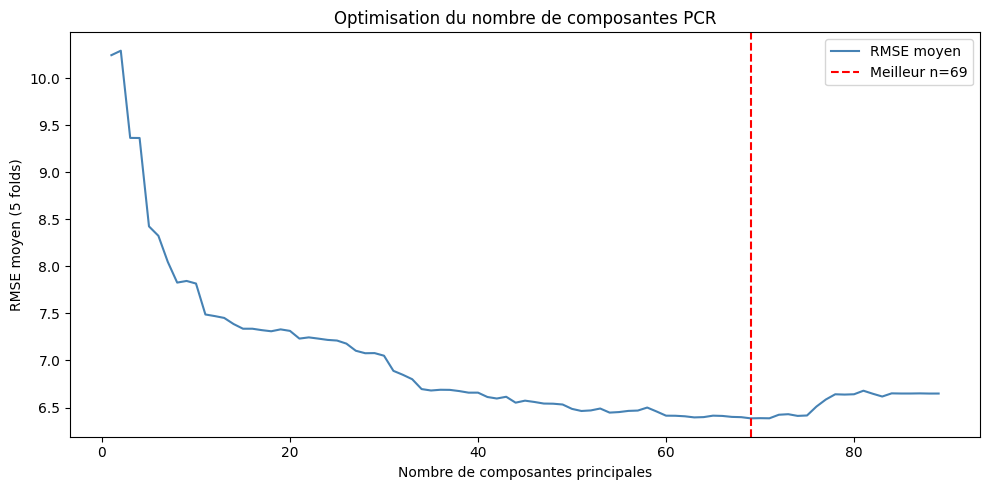

In [14]:
# Optimisation du nombre de composantes principales
n_components_range = range(1, min(X.shape[0], X.shape[1]) + 1)
rmse_means = []
rmse_stds = []

for n in n_components_range:
    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n)),
        ("regression", LinearRegression())
    ])
    scores = cross_val_score(
        pipeline, X, y,
        cv=kf,
        scoring="neg_root_mean_squared_error"
    )
    rmse_means.append(-scores.mean())
    rmse_stds.append(scores.std())

# Meilleur n_components
best_n = n_components_range[np.argmin(rmse_means)]
best_rmse = min(rmse_means)
print(f"Meilleur n_components : {best_n}")
print(f"Meilleur RMSE         : {best_rmse:.4f}")

# Visualisation
plt.figure(figsize=(10, 5))
plt.plot(n_components_range, rmse_means, color="steelblue", label="RMSE moyen")
plt.axvline(best_n, color="red", linestyle="--", label=f"Meilleur n={best_n}")
plt.xlabel("Nombre de composantes principales")
plt.ylabel("RMSE moyen (5 folds)")
plt.title("Optimisation du nombre de composantes PCR")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/pcr_n_components.png", dpi=150, bbox_inches="tight")
plt.show()

##  Entraînement du modèle final
On entraîne le modèle PCR avec le meilleur n_components trouvé.

In [16]:
# Entraînement du modèle final avec le meilleur n_components
pipeline_final = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=best_n)),
    ("regression", LinearRegression())
])

pipeline_final.fit(X, y)

# Evaluation finale sur le train complet
y_pred_train = pipeline_final.predict(X)
rmse_train = np.sqrt(mean_squared_error(y, y_pred_train))

print(f" Modèle PCR entraîné avec n_components={best_n}")
print(f"RMSE sur train complet : {rmse_train:.4f}")
print(f"RMSE cross-validation  : {best_rmse:.4f}")

 Modèle PCR entraîné avec n_components=69
RMSE sur train complet : 5.9547
RMSE cross-validation  : 6.3851


## Prédictions et soumission Kaggle

In [17]:
# Prédictions sur le test
y_pred_test = pipeline_final.predict(X_test)

# Créer le fichier de soumission
submission = pd.DataFrame({
    "Id": test["commune_id"],
    "Predicted": y_pred_test
})

submission.to_csv("../submissions/submission_PCR_v1.csv", index=False)

print(f"Soumission créée : {submission.shape}")
print(submission.head())

Soumission créée : (669, 2)
     Id  Predicted
0    69    48.0021
1   981    37.8211
2  5432    35.1089
3   387    46.1518
4  2194    28.1290
